<a href="https://colab.research.google.com/github/barney-rai/asl-recognition/blob/main/asl_data_proccessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
#import drive
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#check file path
import os

DATA_DIR = "/content/drive/MyDrive/ASL_Project"

print(os.listdir(DATA_DIR))

['A', 'B']


In [ ]:
#check images
print(os.listdir(DATA_DIR + "/A")[:5])
print(os.listdir(DATA_DIR + "/B")[:5])


['A2710.jpg', 'A2654.jpg', 'A2845.jpg', 'A2730.jpg', 'A2643.jpg']
['B2724.jpg', 'B29.jpg', 'B353.jpg', 'B2880.jpg', 'B293.jpg']


In [ ]:
#check count
print("A images:", len(os.listdir(DATA_DIR + "/A")))
print("B images:", len(os.listdir(DATA_DIR + "/B")))

A images: 3000
B images: 3000


In [ ]:
#check names
a_images = os.listdir(DATA_DIR + "/A")

print(a_images[0])

A2710.jpg


In [ ]:
import cv2

In [ ]:
from google.colab.patches import cv2_imshow

In [ ]:
import os

A_DIR = "/content/drive/MyDrive/ASL_Project/A"

print(os.listdir(A_DIR)[:10])

['A2710.jpg', 'A2654.jpg', 'A2845.jpg', 'A2730.jpg', 'A2643.jpg', 'A2694.jpg', 'A2684.jpg', 'A2786.jpg', 'A2863.jpg', 'A2718.jpg']


In [ ]:
filename = os.listdir(A_DIR)[0]

print(filename)

A2710.jpg


In [ ]:
image_path = os.path.join(A_DIR, filename)

print(image_path)

/content/drive/MyDrive/ASL_Project/A/A2710.jpg


In [ ]:
img = cv2.imread(image_path)

In [ ]:
if img is None:
    print("Image failed to load")
else:
    print("Image loaded successfully")

Image loaded successfully


In [ ]:
#height width channel(BGR)
print(img.shape)

(200, 200, 3)


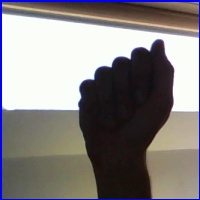

In [ ]:
cv2_imshow(img)

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #grayscale

In [ ]:
print(gray.shape)

(200, 200)


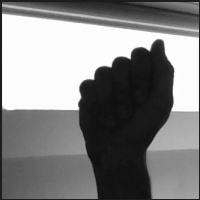

In [ ]:
cv2_imshow(gray)

In [ ]:
print(gray.min())
print(gray.max())

12
255


In [ ]:
resized = cv2.resize(
    gray,
    (64, 64),
    interpolation=cv2.INTER_AREA
)

In [ ]:
print(resized.shape)
print(resized)

(64, 64)
[[ 40  55  54 ...  61  69  57]
 [ 76 150 142 ... 126 122  91]
 [ 62 125 138 ... 125 129 100]
 ...
 [ 50  86  88 ... 158 157 116]
 [ 50  87  90 ... 159 159 118]
 [ 43  69  70 ... 119 119  90]]


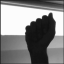

In [ ]:
cv2_imshow(resized)

In [ ]:
print("Original:", img.shape)
print("Grayscale:", gray.shape)
print("Resized:", resized.shape)

Original: (200, 200, 3)
Grayscale: (200, 200)
Resized: (64, 64)


In [ ]:
print("Minimum:", resized.min())
print("Maximum:", resized.max())

Minimum: 16
Maximum: 253


In [6]:
import cv2
import os
import numpy as np

from google.colab.patches import cv2_imshow

In [3]:
A_DIR = "/content/drive/MyDrive/ASL_Project/A"
B_DIR = "/content/drive/MyDrive/ASL_Project/B"

In [8]:
print("A images:", len(os.listdir(A_DIR)))
print("B images:", len(os.listdir(B_DIR)))

A images: 3000
B images: 3000


In [9]:
for filename in os.listdir(A_DIR):
    print(filename)

A2710.jpg
A2654.jpg
A2845.jpg
A2730.jpg
A2643.jpg
A2694.jpg
A2684.jpg
A2786.jpg
A2863.jpg
A2718.jpg
A2638.jpg
A2744.jpg
A2746.jpg
A285.jpg
A280.jpg
A2649.jpg
A2821.jpg
A2656.jpg
A2849.jpg
A2677.jpg
A2828.jpg
A2740.jpg
A2805.jpg
A2747.jpg
A2641.jpg
A2647.jpg
A2830.jpg
A2624.jpg
A275.jpg
A2858.jpg
A2717.jpg
A286.jpg
A2803.jpg
A2646.jpg
A2698.jpg
A2806.jpg
A2804.jpg
A2862.jpg
A2704.jpg
A2753.jpg
A2651.jpg
A2689.jpg
A2725.jpg
A270.jpg
A2673.jpg
A2772.jpg
A2759.jpg
A2837.jpg
A2800.jpg
A2811.jpg
A2752.jpg
A2792.jpg
A2854.jpg
A2672.jpg
A2728.jpg
A2701.jpg
A2875.jpg
A2644.jpg
A2874.jpg
A2735.jpg
A2866.jpg
A2809.jpg
A2733.jpg
A2676.jpg
A2814.jpg
A2628.jpg
A2816.jpg
A283.jpg
A2631.jpg
A2670.jpg
A2778.jpg
A2635.jpg
A2731.jpg
A2857.jpg
A2795.jpg
A2799.jpg
A2685.jpg
A2777.jpg
A2807.jpg
A2645.jpg
A2873.jpg
A277.jpg
A2823.jpg
A2764.jpg
A2666.jpg
A265.jpg
A2619.jpg
A278.jpg
A2742.jpg
A2798.jpg
A2721.jpg
A2714.jpg
A2868.jpg
A2882.jpg
A2766.jpg
A2768.jpg
A2918.jpg
A382.jpg
A315.jpg
A327.jpg
A51.jpg
A433

In [12]:
#testing pipline for A values
images = []
for filename in os.listdir(A_DIR):

    image_path = os.path.join(A_DIR, filename)

    img = cv2.imread(image_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    resized = cv2.resize(
        gray,
        (64, 64),
        interpolation=cv2.INTER_AREA
    )
    images.append(resized)


In [14]:
#function
def load_images(folder):

    images = []

    for filename in os.listdir(folder):

        image_path = os.path.join(folder, filename)

        img = cv2.imread(image_path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        resized = cv2.resize(gray, (64, 64))

        images.append(resized)

    return np.array(images)

In [15]:
A_images = load_images(A_DIR)

print(A_images.shape)

(3000, 64, 64)


In [16]:
B_images = load_images(B_DIR)

print(B_images.shape)

(3000, 64, 64)


In [17]:
X = np.concatenate([A_images, B_images])
print(X.shape)

(6000, 64, 64)


In [18]:
A_labels = np.zeros(len(A_images))
B_labels = np.ones(len(B_images))
y = np.concatenate([A_labels, B_labels])
print(y.shape)

(6000,)


In [19]:
print("Images:", X.shape)
print("Labels:", y.shape)

Images: (6000, 64, 64)
Labels: (6000,)
